In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (mean_squared_error, r2_score,
                              classification_report, confusion_matrix,
                              accuracy_score, roc_curve, auc, roc_auc_score,
                              ConfusionMatrixDisplay)

RANDOM_STATE = 1234

In [12]:
url = 'https://raw.githubusercontent.com/brunolabarre2002-del/m1a1/refs/heads/main/data_sampleA2.txt'
df_raw = pd.read_csv(url)

print(df_raw.shape)
df_raw.info()
df_raw.describe()

(300, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             300 non-null    int64  
 1   customer_size           300 non-null    object 
 2   digital_tenure_months   300 non-null    int64  
 3   share_digital_orders    300 non-null    float64
 4   assortment_coverage     300 non-null    float64
 5   minutes_on_site         300 non-null    float64
 6   avg_minutes_per_page    300 non-null    float64
 7   unique_pages_visited    300 non-null    float64
 8   add_to_cart_count       300 non-null    float64
 9   revome_from_cart_count  300 non-null    float64
 10  minutes_purchase        300 non-null    float64
 11  suggested_purchase      300 non-null    int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 28.3+ KB


,customer_id,digital_tenure_months,share_digital_orders,assortment_coverage,minutes_on_site,avg_minutes_per_page,unique_pages_visited,add_to_cart_count,revome_from_cart_count,minutes_purchase,suggested_purchase
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,6.530000,76.101279,0.100739,90.190075,3.401254,11.013333,12.870000,3.510000,16.376111,0.100000
std,86.746758,3.275903,16.422725,0.082146,170.137405,6.888179,3.004983,10.648838,5.919462,14.414251,0.300501
min,1.000000,0.000000,25.000000,0.010369,1.650762,0.135058,5.000000,2.000000,0.000000,1.000000,0.000000
25%,75.750000,4.000000,66.666667,0.048288,11.057459,0.456320,9.000000,6.000000,0.000000,6.000000,0.000000
50%,150.500000,6.000000,75.000000,0.074762,22.544203,0.847572,11.000000,9.000000,1.000000,12.000000,0.000000
75%,225.250000,9.000000,83.333333,0.124816,74.498591,2.317476,13.000000,16.000000,5.000000,22.000000,0.000000
max,300.000000,15.000000,100.000000,0.578431,1109.440232,50.253500,23.000000,67.000000,52.000000,74.000000,1.000000


In [13]:
# Dummies para customer_size (evitamos dummy trap con drop_first)
dummies = pd.get_dummies(df_raw['customer_size'], prefix='customer_size', drop_first=True).astype('int8')

data = pd.concat([df_raw, dummies], axis=1).drop(columns=['customer_size', 'customer_id']).dropna()
data.head()

,digital_tenure_months,share_digital_orders,assortment_coverage,minutes_on_site,avg_minutes_per_page,unique_pages_visited,add_to_cart_count,revome_from_cart_count,minutes_purchase,suggested_purchase,customer_size_Medium,customer_size_Small,customer_size_Very Large
0,6,88.888889,0.064516,51.914457,2.732340,10.0,3.0,0.0,5.0,0,1,0,0
1,9,100.000000,0.074390,75.566683,0.706231,13.0,32.0,0.0,62.0,0,1,0,0
2,12,50.000000,0.083777,50.861066,0.876915,14.0,22.0,0.0,31.0,0,1,0,0
3,9,75.000000,0.042476,120.077884,13.341987,7.0,3.0,13.0,1.0,1,0,1,0
4,6,75.000000,0.089535,21.776023,1.036953,9.0,10.0,0.0,8.0,0,0,0,0


# Consigna 1 — Regresión (variable respuesta: share_digital_orders)

Problema: estimar qué porcentaje de los pedidos de un cliente se hacen por canal digital (share_digital_orders), en función de su perfil (tamaño), antigüedad digital, comportamiento de navegación y compra.

In [14]:
features_full = ['customer_size_Small', 'customer_size_Medium', 'customer_size_Very Large',
                  'digital_tenure_months', 'assortment_coverage', 'minutes_on_site',
                  'avg_minutes_per_page', 'unique_pages_visited', 'add_to_cart_count',
                  'revome_from_cart_count', 'minutes_purchase', 'suggested_purchase']

X = data[features_full]
y = data['share_digital_orders']

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE)

ols_full = sm.OLS(y_trainval, sm.add_constant(X_trainval)).fit()
print(ols_full.summary())

                             OLS Regression Results                             
Dep. Variable:     share_digital_orders   R-squared:                       0.093
Model:                              OLS   Adj. R-squared:                  0.045
Method:                   Least Squares   F-statistic:                     1.935
Date:                  Thu, 20 Aug 2026   Prob (F-statistic):             0.0315
Time:                          16:04:52   Log-Likelihood:                -1001.4
No. Observations:                   240   AIC:                             2029.
Df Residuals:                       227   BIC:                             2074.
Df Model:                            12                                         
Covariance Type:              nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
cons

Con las 12 variables el modelo apenas es significativo en conjunto (F p≈0.03) y R² = 0.09: ninguna variable individual es significativa al 5%. Esto ya anticipa que share_digital_orders está débilmente explicada por estos predictores.

In [15]:
Xc = sm.add_constant(X_trainval)
vif = pd.DataFrame({
    'variable': Xc.columns,
    'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
})
print(vif.sort_values('VIF', ascending=False))

                    variable        VIF
0                      const  36.030047
5        assortment_coverage   4.151951
7       avg_minutes_per_page   3.774994
6            minutes_on_site   3.746913
3   customer_size_Very Large   2.990198
1        customer_size_Small   2.329453
9          add_to_cart_count   1.978206
2       customer_size_Medium   1.823653
8       unique_pages_visited   1.360803
11          minutes_purchase   1.307479
12        suggested_purchase   1.232754
10    revome_from_cart_count   1.196143
4      digital_tenure_months   1.098153


assortment_coverage, minutes_on_site y avg_minutes_per_page tienen VIF entre 3.7 y 4.2 — colinealidad. Igual las dejamos afuera del modelo reducido porque son conceptualmente redundantes (todas miden "tiempo/cobertura en el sitio").

In [16]:
features_red = ['customer_size_Small', 'customer_size_Medium', 'customer_size_Very Large',
                 'digital_tenure_months', 'minutes_on_site', 'unique_pages_visited',
                 'add_to_cart_count', 'revome_from_cart_count', 'minutes_purchase',
                 'suggested_purchase']

def evaluar_lineal(feat_list, X_trainval_all, y_trainval, X_test_all, y_test, nombre):
    Xtv, Xte = X_trainval_all[feat_list], X_test_all[feat_list]
    modelo = LinearRegression().fit(Xtv, y_trainval)
    pred = modelo.predict(Xte)
    print(f"{nombre}: R2 test = {r2_score(y_test, pred):.3f} | RMSE test = {np.sqrt(mean_squared_error(y_test, pred)):.2f}")
    return modelo

_ = evaluar_lineal(features_full, X_trainval, y_trainval, X_test, y_test, "Lineal completo")
_ = evaluar_lineal(features_red,  X_trainval, y_trainval, X_test, y_test, "Lineal reducido (sin colineales)")

Lineal completo: R2 test = -0.001 | RMSE test = 15.78
Lineal reducido (sin colineales): R2 test = 0.024 | RMSE test = 15.58


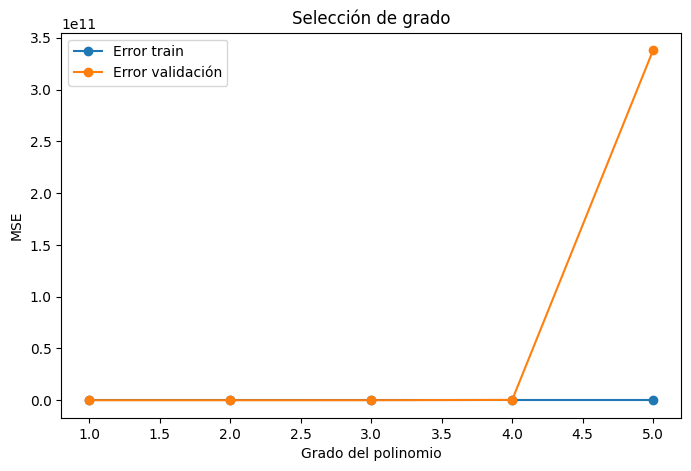

Grado 1: MSE val = 323.94
Grado 2: MSE val = 662.71
Grado 3: MSE val = 17334434.46
Grado 4: MSE val = 305281415.95
Grado 5: MSE val = 338026237856.67


In [17]:
X_red_train, X_red_val = X_train[features_red], X_val[features_red]

degrees = range(1, 6)
train_err, val_err = [], []

for d in degrees:
    modelo_d = make_pipeline(PolynomialFeatures(d), LinearRegression())
    modelo_d.fit(X_red_train, y_train)
    train_err.append(mean_squared_error(y_train, modelo_d.predict(X_red_train)))
    val_err.append(mean_squared_error(y_val, modelo_d.predict(X_red_val)))

plt.figure(figsize=(8,5))
plt.plot(degrees, train_err, marker='o', label='Error train')
plt.plot(degrees, val_err, marker='o', label='Error validación')
plt.xlabel('Grado del polinomio'); plt.ylabel('MSE'); plt.legend(); plt.title('Selección de grado')
plt.show()

for d, e in zip(degrees, val_err):
    print(f"Grado {d}: MSE val = {e:.2f}")

A partir de grado 2 el MSE de validación explota (overfitting severo con tantas variables cruzadas y solo 192 observaciones de train). El mínimo real está en grado 1, es decir, el modelo lineal simple es el que mejor generaliza — no un polinomio.

MAE:  13.11
RMSE: 15.58
R2 test: 0.024


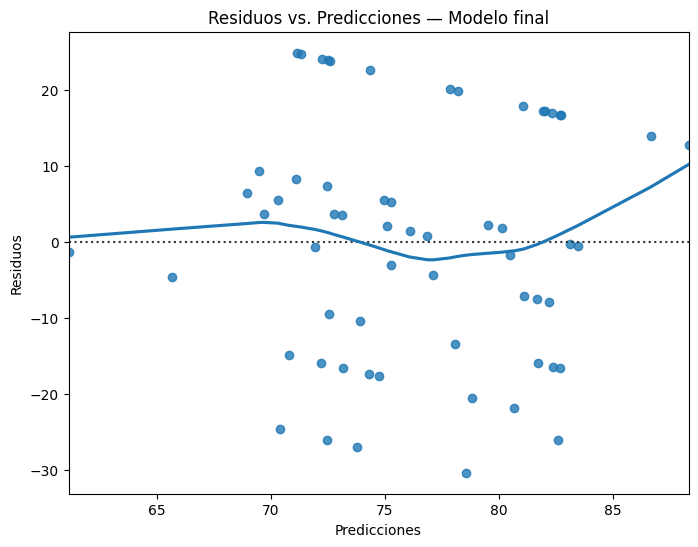

In [18]:
modelo_final_reg = LinearRegression().fit(X_trainval[features_red], y_trainval)
pred_test = modelo_final_reg.predict(X_test[features_red])

print(f"MAE:  {mean_absolute_error(y_test, pred_test):.2f}" if False else
      f"MAE:  {np.mean(np.abs(y_test-pred_test)):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test)):.2f}")
print(f"R2 test: {r2_score(y_test, pred_test):.3f}")

resid = y_test - pred_test
fig, ax = plt.subplots(figsize=(8,6))
sns.residplot(x=pred_test, y=resid, lowess=True, ax=ax)
ax.set_xlabel('Predicciones'); ax.set_ylabel('Residuos')
ax.set_title('Residuos vs. Predicciones — Modelo final')
plt.show()

Conclusión Consigna 1: el mejor modelo entre los evaluados es la regresión lineal múltiple con el set de variables reducido (sin assortment_coverage ni avg_minutes_per_page, redundantes con minutes_on_site). Los modelos polinómicos de grado ≥2 no aportan mejora — al contrario, sobreajustan y explotan el error de validación por la combinación de pocas observaciones (300 en total) y muchas variables. Aun así, el poder explicativo del mejor modelo es bajo (R² test ≈ 0.02–0.09): el comportamiento digital del cliente medido por estas variables explica muy poco de share_digital_orders. Esto sugiere que faltan predictores relevantes no incluidos en la base (por ejemplo, precio, categoría de producto, estacionalidad), más que un problema de forma funcional.

# Consigna 2 — Regresión logística (variable respuesta: suggested_purchase)

Problema: estimar la probabilidad de que la compra de un cliente haya sido producto de una sugerencia/recomendación (suggested_purchase = 1) en función de su comportamiento de navegación y carrito.

suggested_purchase
0    90.0
1    10.0
Name: proportion, dtype: float64


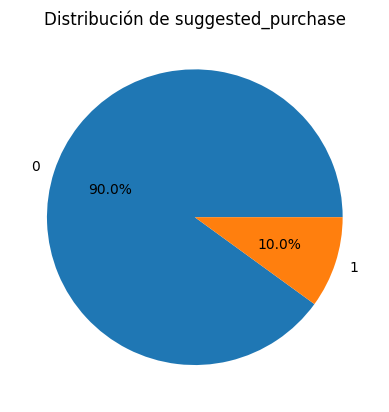

In [19]:
print(data['suggested_purchase'].value_counts(normalize=True).mul(100).round(1))
data['suggested_purchase'].value_counts().plot.pie(autopct='%1.1f%%', ylabel='')
plt.title('Distribución de suggested_purchase')
plt.show()

La clase positiva (1) representa apenas el 10% de los casos: cualquier evaluación posterior tiene que mirar más allá del accuracy.

In [20]:
features_logit = ['digital_tenure_months', 'share_digital_orders', 'assortment_coverage',
                   'minutes_on_site', 'avg_minutes_per_page', 'unique_pages_visited',
                   'add_to_cart_count', 'revome_from_cart_count', 'minutes_purchase',
                   'customer_size_Small', 'customer_size_Medium', 'customer_size_Very Large']

X_logit = sm.add_constant(data[features_logit])
y_logit = data['suggested_purchase']

logit_full = sm.Logit(y_logit, X_logit).fit(disp=0)
print(logit_full.summary())

                           Logit Regression Results                           
Dep. Variable:     suggested_purchase   No. Observations:                  300
Model:                          Logit   Df Residuals:                      287
Method:                           MLE   Df Model:                           12
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                  0.2963
Time:                        16:04:53   Log-Likelihood:                -68.628
converged:                       True   LL-Null:                       -97.525
Covariance Type:            nonrobust   LLR p-value:                 5.682e-08
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.4166      1.975      0.717      0.473      -2.455       5.288
digital_tenure_months       -0.0108      0.076     -0.142      0.887      -0.159       0.

Con p<0.05 sobreviven solo tres variables: unique_pages_visited, add_to_cart_count y revome_from_cart_count. El resto (antigüedad, tamaño de cliente, tiempo en sitio, etc.) no aporta señal.

In [21]:
feats_sig = ['revome_from_cart_count', 'unique_pages_visited', 'add_to_cart_count']
X_sig = sm.add_constant(data[feats_sig])

logit_red = sm.Logit(y_logit, X_sig).fit(disp=0)
print(logit_red.summary())

odds = np.exp(logit_red.params)
print("\nOdds Ratios:\n", odds)

                           Logit Regression Results                           
Dep. Variable:     suggested_purchase   No. Observations:                  300
Model:                          Logit   Df Residuals:                      296
Method:                           MLE   Df Model:                            3
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                  0.2418
Time:                        16:04:53   Log-Likelihood:                -73.940
converged:                       True   LL-Null:                       -97.525
Covariance Type:            nonrobust   LLR p-value:                 3.200e-10
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5614      0.976      2.625      0.009       0.649       4.474
revome_from_cart_count     0.1174      0.035      3.311      0.001       0.048       0.187
uniq

Interpretación de Odds Ratios:

revome_from_cart_count (OR≈1.12): cada ítem removido del carrito aumenta ~12% las chances de recibir/aceptar una sugerencia — señal de indecisión que el sistema de recomendación "capta".
unique_pages_visited (OR≈0.67): cada página adicional visitada reduce ~33% esas chances — cliente que ya explora mucho necesita menos empujón.
add_to_cart_count (OR≈0.85): cada ítem agregado al carrito reduce ~15% las chances — cliente que ya sabe qué quiere depende menos de sugerencias.

In [22]:
pred_prob = logit_red.predict(X_sig)
pred_class = (pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_logit, pred_class)
print("Matriz de confusión:\n", cm)
print(f"Accuracy: {accuracy_score(y_logit, pred_class):.4f}")

VN, FP, FN, VP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"Sensibilidad (recall clase 1): {VP/(VP+FN):.2f}")
print(f"Especificidad (recall clase 0): {VN/(VN+FP):.2f}")

Matriz de confusión:
 [[269   1]
 [ 24   6]]
Accuracy: 0.9167
Sensibilidad (recall clase 1): 0.20
Especificidad (recall clase 0): 1.00


Accuracy 91.7% es engañoso: sensibilidad ≈0.20 (solo detecta 1 de cada 5 casos "sugiere"). Con 90/10 de desbalance, el modelo "gana" prediciendo casi siempre 0.

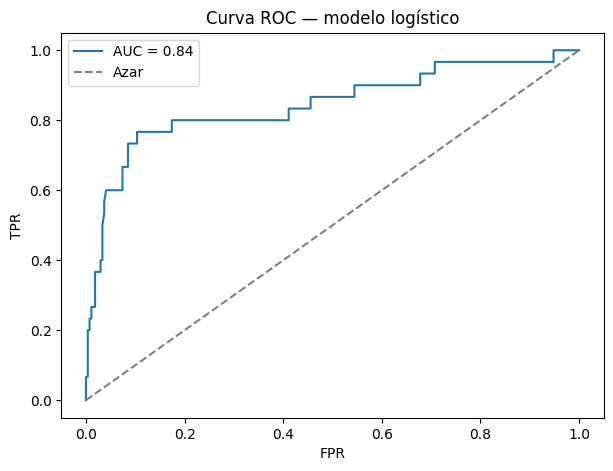

In [23]:
fpr, tpr, _ = roc_curve(y_logit, pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], '--', color='grey', label='Azar')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('Curva ROC — modelo logístico')
plt.show()

AUC≈0.84: el modelo sí discrimina bien entre clases; el problema de la Celda 12 es el umbral (0.5), no el modelo.

In [24]:
X_final = data[feats_sig]
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_logit, test_size=0.2, random_state=42, stratify=y_logit
)

logr_base = LogisticRegression().fit(X_train, y_train)
pred_base = logr_base.predict(X_test)
print(classification_report(y_test, pred_base, target_names=['No sugiere (0)', 'Sugiere (1)']))

                precision    recall  f1-score   support

No sugiere (0)       0.96      1.00      0.98        54
   Sugiere (1)       1.00      0.67      0.80         6

      accuracy                           0.97        60
     macro avg       0.98      0.83      0.89        60
  weighted avg       0.97      0.97      0.96        60



In [25]:
pipe_lr = Pipeline([('sc', StandardScaler()), ('LR', LogisticRegression(max_iter=10000))])
params_lr = {
    'LR__C': np.logspace(-2, 4, 7),
    'LR__solver': ['liblinear', 'lbfgs'],
    'LR__class_weight': [None, 'balanced']
}
search_lr = GridSearchCV(pipe_lr, params_lr, cv=5, scoring='roc_auc')
search_lr.fit(X_train, y_train)

print("Mejor AUC (CV):", search_lr.best_score_)
print("Mejores parámetros:", search_lr.best_params_)

Mejor AUC (CV): 0.8660729386892179
Mejores parámetros: {'LR__C': np.float64(1.0), 'LR__class_weight': None, 'LR__solver': 'liblinear'}


GridSearchCV confirma AUC de validación cruzada ≈0.87 con C≈1.0, solver='liblinear', class_weight=None.

In [26]:
modelo_opt = search_lr.best_estimator_
pred_opt = modelo_opt.predict(X_test)
print("--- Modelo optimizado (class_weight=None) ---")
print(classification_report(y_test, pred_opt, target_names=['No sugiere (0)', 'Sugiere (1)']))
print("AUC test:", roc_auc_score(y_test, modelo_opt.predict_proba(X_test)[:,1]))

modelo_bal = LogisticRegression(C=10, solver='liblinear', class_weight='balanced').fit(X_train, y_train)
pred_bal = modelo_bal.predict(X_test)
print("\n--- Modelo balanceado (class_weight='balanced') ---")
print(classification_report(y_test, pred_bal, target_names=['No sugiere (0)', 'Sugiere (1)']))
print("AUC test:", roc_auc_score(y_test, modelo_bal.predict_proba(X_test)[:,1]))

--- Modelo optimizado (class_weight=None) ---
                precision    recall  f1-score   support

No sugiere (0)       0.95      1.00      0.97        54
   Sugiere (1)       1.00      0.50      0.67         6

      accuracy                           0.95        60
     macro avg       0.97      0.75      0.82        60
  weighted avg       0.95      0.95      0.94        60

AUC test: 0.7530864197530864

--- Modelo balanceado (class_weight='balanced') ---
                precision    recall  f1-score   support

No sugiere (0)       0.95      0.76      0.85        54
   Sugiere (1)       0.24      0.67      0.35         6

      accuracy                           0.75        60
     macro avg       0.59      0.71      0.60        60
  weighted avg       0.88      0.75      0.80        60

AUC test: 0.7407407407407408


In [27]:
probs_opt = modelo_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs_opt)
umbral_optimo = thresholds[np.argmax(tpr - fpr)]  # índice de Youden

pred_umbral = (probs_opt >= umbral_optimo).astype(int)
print(f"Umbral óptimo (Youden): {umbral_optimo:.3f}")
print(classification_report(y_test, pred_umbral, target_names=['No sugiere (0)', 'Sugiere (1)']))

Umbral óptimo (Youden): 0.469
                precision    recall  f1-score   support

No sugiere (0)       0.96      1.00      0.98        54
   Sugiere (1)       1.00      0.67      0.80         6

      accuracy                           0.97        60
     macro avg       0.98      0.83      0.89        60
  weighted avg       0.97      0.97      0.96        60



Esta es la mejora sobre el original: en vez de forzar class_weight='balanced' (que sacrifica mucha precisión), se puede mover el umbral de decisión sobre el modelo ya optimizado por AUC. Es una forma más quirúrgica de subir el recall de la clase minoritaria sin descartar el modelo con mejor poder discriminativo.

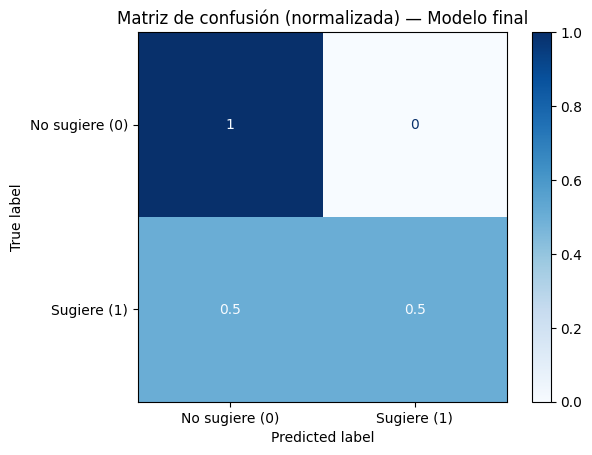

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_opt,
    display_labels=['No sugiere (0)', 'Sugiere (1)'],
    cmap='Blues', normalize='true'
)
plt.title('Matriz de confusión (normalizada) — Modelo final')
plt.show()

El modelo logístico con las tres variables significativas (revome_from_cart_count, unique_pages_visited, add_to_cart_count) tiene buen poder discriminativo global (AUC≈0.84 en la muestra completa, ≈0.75–0.87 en validación/test), pero el desbalance 90/10 hace que el umbral por default (0.5) sea demasiado conservador: alta precisión y especificidad, pero recall bajo para la clase de interés.

Hay dos caminos razonables según el objetivo de negocio:

Si el costo de una sugerencia "de más" es bajo, conviene el modelo balanceado (recall≈0.67, pero precisión cae a ≈0.24).
Si se quiere preservar precisión, conviene el modelo optimizado por AUC + ajuste de umbral (Celda 17), que mejora el recall sin resignar tanta precisión como el balanceo forzado.

No hay un "mejor modelo" único: la elección depende de si el negocio prioriza no generar sugerencias irrelevantes (precisión) o no perderse casos donde la sugerencia sí funciona (recall).